# Summarizing the Group of Gait Cycles in a Session

After segmenting a session we end up with a group of similar gait cycles.
If inspected, we see that there is a lot of variability within a session.

In this notebook we will explore how to group them together to obtain the best represenration of the group.

In [1]:
from core.matlab_data_loader import MatlabDataLoader, segment_ts_by_stance_phase
from core.timeseries import get_group_curves, plot_group_curves, apply_continuous_curve_registration
import kineticstoolkit as ktk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, envelope, hilbert
from scipy.interpolate import interp1d
import dtw as dtw

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
loader = MatlabDataLoader()

first_session_id = loader.get_successful_sessions()[0]
print("First session id: ", first_session_id)

L_KNEE_MARKER = "L_shank_1"
L_KNEE_JOINT = "L_knee"

# Raw
l_shank_1_marker_data = loader.get_marker_data(first_session_id, L_KNEE_MARKER)
l_knee_angle_data = loader.get_joint_angles(first_session_id, L_KNEE_JOINT, normalized=False)
l_knee_velocity_data = loader.get_joint_velocities(first_session_id, L_KNEE_JOINT, normalized=False)

# Normalisedb
l_knee_normalized_angle_data = loader.get_joint_angles(first_session_id, L_KNEE_JOINT, normalized=True)
l_knee_normalized_velocity_data = loader.get_joint_velocities(first_session_id, L_KNEE_JOINT, normalized=True)

First session id:  100001_20110531T161051


In [3]:
full_data = loader.get_discrete_with_metadata()
print(full_data.info(verbose=True))
display(full_data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812 entries, 0 to 1811
Data columns (total 89 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              1812 non-null   object 
 1   Speed_Output                    1812 non-null   float64
 2   Label                           1812 non-null   object 
 3   Hz                              1812 non-null   int64  
 4   Step_Width_Left                 1812 non-null   float64
 5   Step_Width_Right                1812 non-null   float64
 6   Stride_Rate_Left                1812 non-null   float64
 7   Stride_Rate_Right               1812 non-null   float64
 8   Stride_Length_Left              1812 non-null   float64
 9   Stride_Length_Right             1812 non-null   float64
 10  Swing_Time_Left                 1812 non-null   float64
 11  Swing_Time_Right                1812 non-null   float64
 12  Stance_Time_Left                18

,ID,Speed_Output,Label,Hz,Step_Width_Left,Step_Width_Right,Stride_Rate_Left,Stride_Rate_Right,Stride_Length_Left,Stride_Length_Right,...,Hip_Add_Peak_Vel_Right,Pelvic_Drop_Peak_Vel_Left,Pelvic_Drop_Peak_Vel_Right,Vertical_Oscillation_Left,Vertical_Oscillation_Right,id,sub_id,age,Gender,injury_code
0,100001_20110531T161051,2.489233,run,200,0.123419,0.123419,78.947368,78.947368,1.891817,1.891817,...,87.908897,-82.090017,-57.417845,96.433793,92.586134,100001_20110531T161051,100001,47.0,female,achi_tend
1,100002_20110601T140505,2.722687,run,200,0.032922,0.032922,81.632653,81.632653,2.001175,2.001175,...,123.900795,-57.724685,-60.462411,86.521432,94.945518,100002_20110601T140505,100002,37.0,male,itb_synd
2,100003_20110601T095930,2.949904,run,200,0.097273,0.097273,78.947368,78.947368,2.241927,2.241927,...,161.075363,-82.171073,-95.302664,82.680986,76.611379,100003_20110601T095930,100003,51.0,male,pate_pain_synd
3,100004_20110203T120721,2.688014,run,200,0.011401,0.011401,82.191781,82.191781,1.962250,1.962250,...,123.606287,-63.319119,-49.646132,92.593339,83.273183,100004_20110203T120721,100004,35.0,male,calf_musc_stra
4,100004_20140929T102035,2.928598,run,200,0.029021,0.029021,83.333333,82.758621,2.108590,2.123233,...,129.000180,-32.717949,-52.004473,87.481400,75.091789,100004_20140929T102035,100004,39.0,male,no_injury


In [4]:
discrete_variables = loader.get_discrete_variables()
session_data_full_cleaned = loader.get_session_data_full_cleaned()

# Find rows present in discrete_variables but missing in session_data_full_cleaned (by session id)
missing_in_metadata = discrete_variables[~discrete_variables['ID'].isin(session_data_full_cleaned['id'])]
print("Rows in discrete_variables missing from session_data_full_cleaned (by ID):")
display(missing_in_metadata)

# Find rows present in session_data_full_cleaned but missing in discrete_variables (by session id)
missing_in_discrete = session_data_full_cleaned[~session_data_full_cleaned['id'].isin(discrete_variables['ID'])]
print("Rows in session_data_full_cleaned missing from discrete_variables (by id):")
display(missing_in_discrete)

Rows in discrete_variables missing from session_data_full_cleaned (by ID):


,ID,Speed_Output,Label,Hz,Step_Width_Left,Step_Width_Right,Stride_Rate_Left,Stride_Rate_Right,Stride_Length_Left,Stride_Length_Right,...,Pronation_Onset_Left,Pronation_Onset_Right,Supination_Timing_Left,Supination_Timing_Right,Hip_Add_Peak_Vel_Left,Hip_Add_Peak_Vel_Right,Pelvic_Drop_Peak_Vel_Left,Pelvic_Drop_Peak_Vel_Right,Vertical_Oscillation_Left,Vertical_Oscillation_Right
1731,200375_20140502T074159,2.961155,run,200,0.009988,0.009988,86.956522,86.330935,2.043197,2.058002,...,24,21,69,60,179.410472,285.994694,-104.584953,-115.550193,99.817207,106.338296


Rows in session_data_full_cleaned missing from discrete_variables (by id):


,id,sub_id,datestring,filename,speed_r,age,Height,Weight,Gender,DominantLeg,...,injury_desc,injury2_desc,injury_name,injury2_name,injured_joint_code,injured_joint2_code,injured_side_code,injured_side2_code,has_no_injury,is_injured
246,101146_20140707T124250,101146,2014-07-07 12:42:50,20140707t124250.json,1.885087,44.0,158.0,57.3,female,left,...,General sensation of discomfort without speci...,General sensation of discomfort without speci...,pain,pain,sacro_joint,knee,right,right,False,True
267,101164_20140811T103911,101164,2014-08-11 10:39:11,20140811t103911.json,2.375675,27.0,170.0,62.6,female,right,...,Inflammation of tendons around the outer ankle...,No injury has been diagnosed.,peroneal tendonitis,no injury,lower_leg,no_injury,right,no_injury,False,True
748,100218_20110921T141851,100218,2011-09-21 14:18:51,20110921t141851.json,2.526876,52.0,170.7,72.0,male,left,...,Inflammation or irritation of Achilles tendon ...,No injury has been diagnosed.,achilles tendonitis,no injury,ankle,no_injury,bilateral,right,False,True
805,100390_20120315T133207,100390,2012-03-15 13:32:07,20120315t133207.json,2.695787,27.0,182.0,70.5,male,left,...,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,right,right,True,False
1048,101413_20150402T122006,101413,2015-04-02 12:20:06,20150402t122006.json,2.753896,22.0,164.0,59.8,female,right,...,Pain around kneecap caused by poor tracking an...,No injury has been diagnosed.,patellofemoral pain syndrome,no injury,knee,no_injury,right,no_injury,False,True
1196,100313_20110209T125643,100313,2011-11-04 13:33:06,20110209t125643.json,2.677754,46.0,153.8,61.6,female,left,...,Pain around kneecap caused by poor tracking an...,No injury has been diagnosed.,patellofemoral pain syndrome,no injury,knee,no_injury,left,right,False,True
1206,100319_20110408T122343,100319,2011-11-07 13:56:55,20110408t122343.json,2.679525,43.0,165.7,68.9,female,left,...,Pain around kneecap caused by poor tracking an...,No injury has been diagnosed.,patellofemoral pain syndrome,no injury,knee,no_injury,left,right,False,True
1433,200241_20140204T123534,200241,2014-02-04 12:35:34,20140204t123534.json,4.154845,28.0,171.0,64.0,male,right,...,Overstretching or tearing of the calf muscle f...,No injury has been diagnosed.,calf muscle strain,no injury,lower_leg,no_injury,right,no_injury,False,True
1469,200250_20140407T113504,200250,2014-04-07 11:35:04,20140407t113504.json,3.852247,26.0,164.0,47.0,female,right,...,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,True,False
1477,200251_20140408T134209,200251,2014-04-08 13:42:09,20140408t134209.json,3.675750,63.0,153.0,54.0,female,right,...,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,hip_pelvis,no_injury,right,no_injury,False,True


In [5]:
print("L_knee normalized Angle data shape:", l_knee_normalized_angle_data.shape)
print("\nFirst few rows:")
print(l_knee_normalized_angle_data.head())
print("\nData info:")
print(l_knee_normalized_angle_data.info())

print("\nL_knee angle data shape:", l_knee_angle_data.shape)
print("\nFirst few rows:")
print(l_knee_angle_data.head())
print("\nData info:")
print(l_knee_angle_data.info())

L_knee normalized Angle data shape: (101, 4)

First few rows:
   PercentGaitCycle     X_deg     Y_deg     Z_deg
0          0.990099 -3.318307 -3.991331 -3.602910
1          1.980198 -3.446051 -4.141391 -3.720143
2          2.970297 -3.574228 -4.297134 -3.838855
3          3.960396 -3.702452 -4.458029 -3.958587
4          4.950495 -3.827711 -4.618412 -4.073492

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PercentGaitCycle  101 non-null    float64
 1   X_deg             101 non-null    float64
 2   Y_deg             101 non-null    float64
 3   Z_deg             101 non-null    float64
dtypes: float64(4)
memory usage: 3.3 KB
None

L_knee angle data shape: (4000, 4)

First few rows:
   TimeIndex      X_deg     Y_deg      Z_deg
0          1  -8.981527 -7.752238  20.139146
1          2  -9.485651 -7.734218  22.084077
2      

In [6]:
print("Gait events:")
events = loader.get_gait_events(first_session_id)
print("\nShape:")
print(events.shape)
print("\nFirst few rows:")
display(events.head())
print("\nData info:")
print(events.info())

Gait events:

Shape:
(22, 9)

First few rows:


,EventNumber,L_TD,L_Midstance,L_TO,L_heelwhip,R_TD,R_Midstance,R_TO,R_heelwhip
0,1,235,267,299,323.0,309,344,378,409.0
1,2,386,418,450,475.0,459,493,526,565.0
2,3,536,568,599,626.0,609,644,678,717.0
3,4,688,720,751,781.0,762,796,829,869.0
4,5,840,873,905,931.0,914,948,981,1011.0



Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   EventNumber  22 non-null     int64  
 1   L_TD         22 non-null     int64  
 2   L_Midstance  22 non-null     int64  
 3   L_TO         22 non-null     int64  
 4   L_heelwhip   21 non-null     float64
 5   R_TD         22 non-null     int64  
 6   R_Midstance  22 non-null     int64  
 7   R_TO         22 non-null     int64  
 8   R_heelwhip   21 non-null     float64
dtypes: float64(2), int64(7)
memory usage: 1.7 KB
None


In [7]:
l_touchdown_events = events["L_TD"].to_list()
l_toe_off_events = events["L_TO"].to_list()
r_touchdown_events = events["R_TD"].to_list()
r_toe_off_events = events["R_TO"].to_list()

ts = loader.get_joint_angles_timeseries(first_session_id, "L_knee", normalized=False, include_events=True)
print(ts)
print(ts.data_info)

TimeSeries with attributes:
         time: array([ 1, 2, 3, ..., 3998, 3999, 4000])
         data: <dict with 1 entries>
    time_info: {'Unit': 's'}
    data_info: <dict with 1 entries>
       events: <list of 44 items>

{'Metadata': {'session_id': '100001_20110531T161051', 'hz': '200', 'speed': '2.48923339634983', 'age': '47.0', 'gender': 'female', 'height': '172.0', 'weight': '61.9', 'dominant_leg': 'left', 'injury_code': 'achi_tend', 'injured_side_code': 'left', 'injury_severity_code': 'train_in_pain', 'injured_joint_code': 'ankle'}}


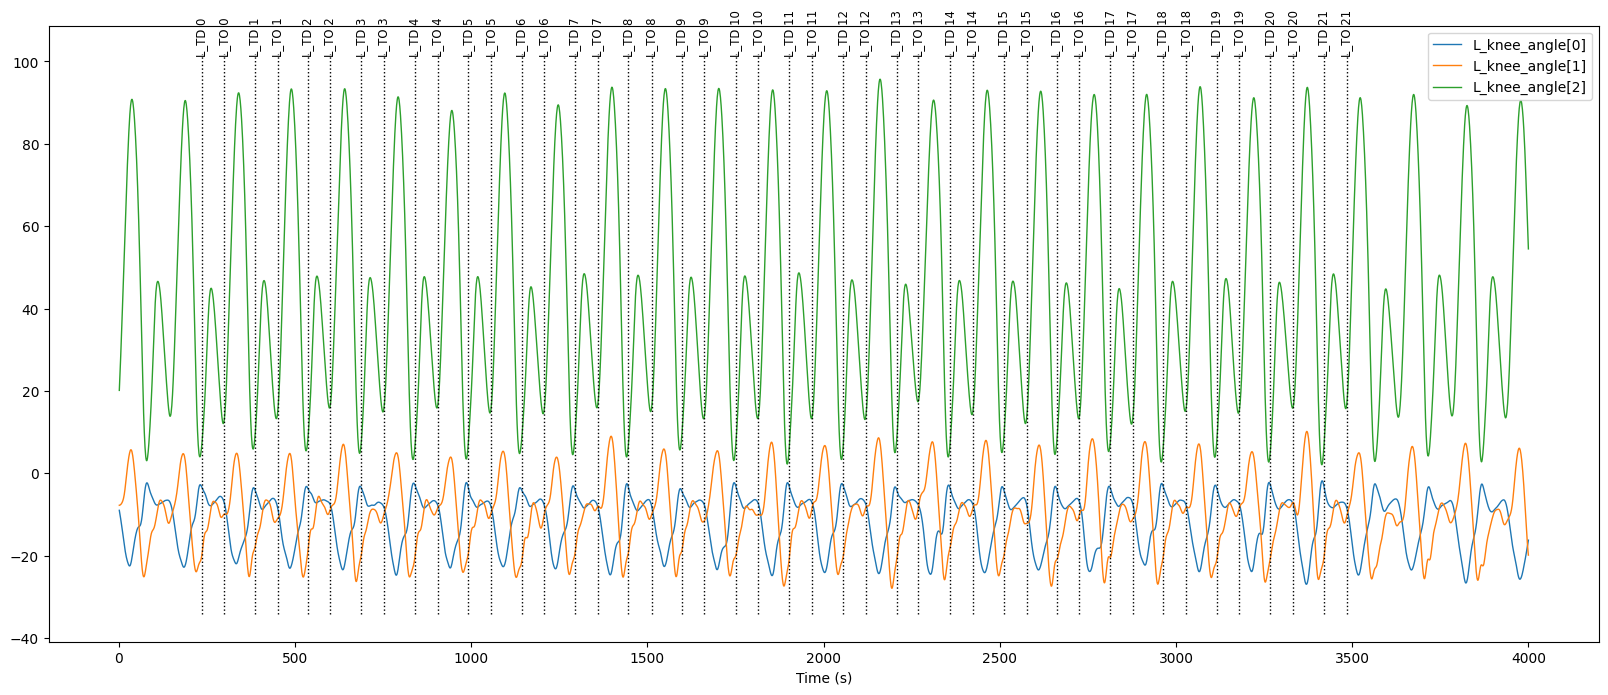

In [8]:
plt.figure(figsize=(20, 8))
ts.plot()

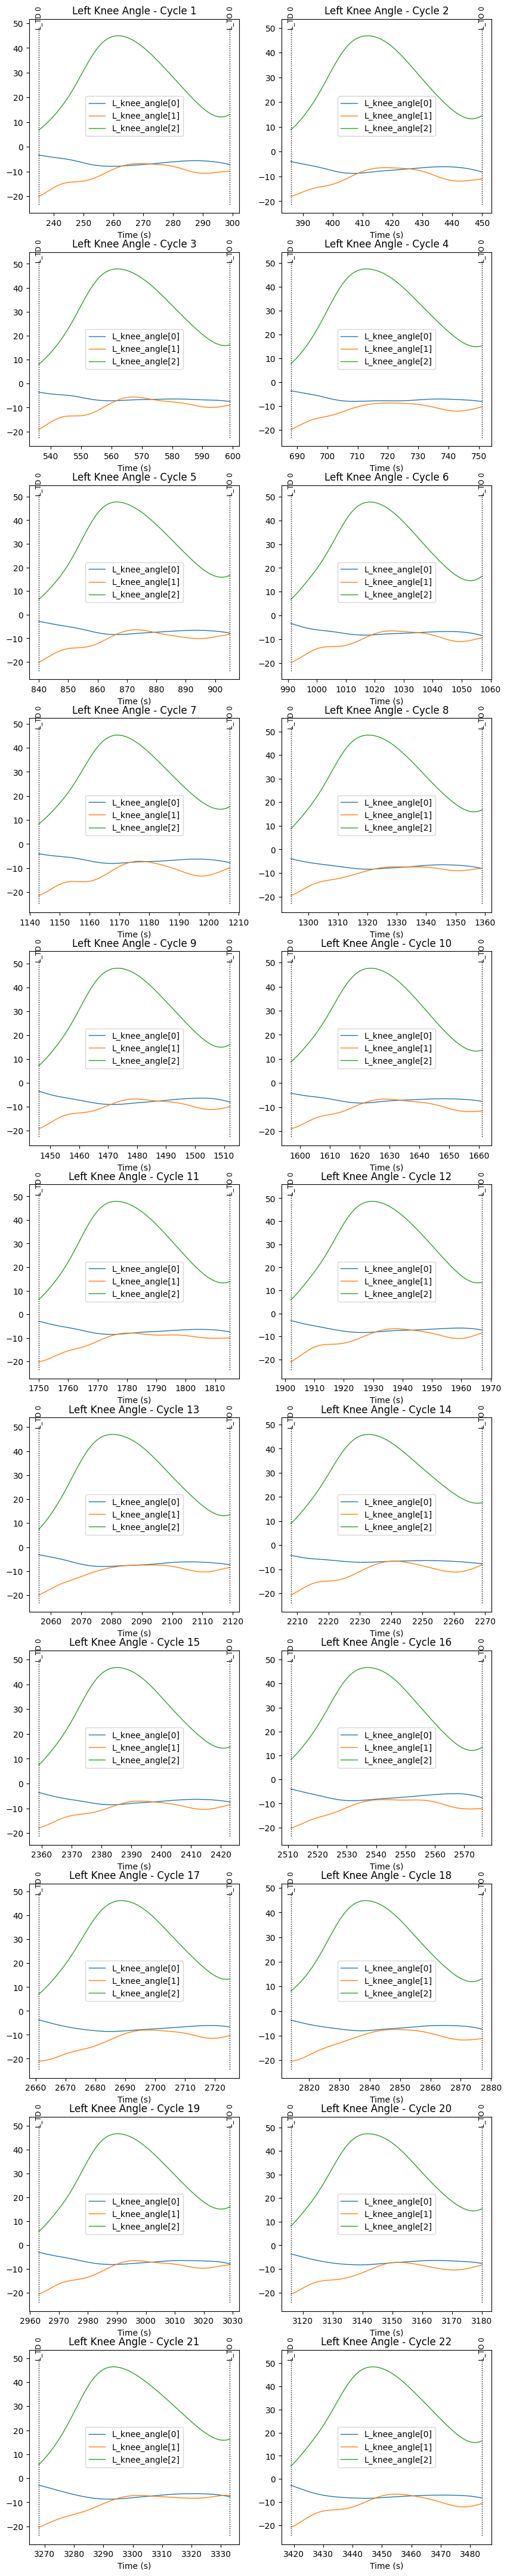

In [9]:
max_cycles = len(l_touchdown_events)

ncols = 2
nrows = (max_cycles + ncols - 1) // ncols

segments = segment_ts_by_stance_phase(ts, "L")

plt.figure(figsize=(10, 5 * nrows))
for i, segment in enumerate(segments):
    plt.subplot(nrows, ncols, i+1)
    segment.plot()
    plt.title(f"Left Knee Angle - Cycle {i+1}")

plt.show()

Segment lengths:
Min: 62
Max: 67
Mean: 65.27272727272727
Median: 65.0
Std: 1.1748043621200077


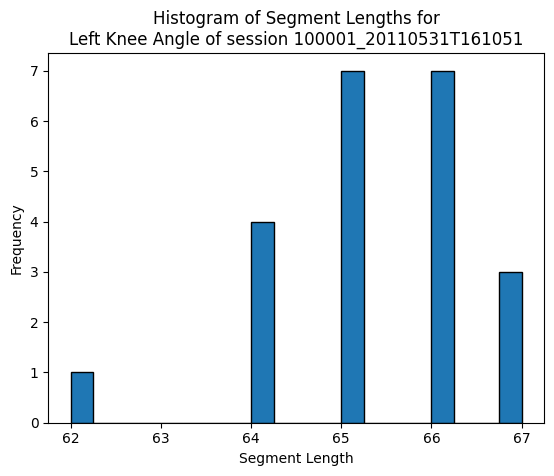

In [10]:
segment_lengths = [len(segment.time) for segment in segments]

print("Segment lengths:")
print("Min:", min(segment_lengths))
print("Max:", max(segment_lengths))
print("Mean:", sum(segment_lengths) / len(segment_lengths))
print("Median:", np.median(segment_lengths))
print("Std:", np.std(segment_lengths))

plt.hist(segment_lengths, bins=20, edgecolor='black')
plt.xlabel('Segment Length')
plt.ylabel('Frequency')
plt.title('Histogram of Segment Lengths for\nLeft Knee Angle of session {}'.format(first_session_id))
plt.show()

In [11]:
discrete_variables = loader.get_discrete_variables()
session_data_full_cleaned = loader.get_session_data_full_cleaned()

# Find rows present in discrete_variables but missing in session_data_full_cleaned (by session id)
missing_in_metadata = discrete_variables[~discrete_variables['ID'].isin(session_data_full_cleaned['id'])]
print("Rows in discrete_variables missing from session_data_full_cleaned (by ID):")
display(missing_in_metadata)

# Find rows present in session_data_full_cleaned but missing in discrete_variables (by session id)
missing_in_discrete = session_data_full_cleaned[~session_data_full_cleaned['id'].isin(discrete_variables['ID'])]
print("Rows in session_data_full_cleaned missing from discrete_variables (by id):")
display(missing_in_discrete)

Rows in discrete_variables missing from session_data_full_cleaned (by ID):


,ID,Speed_Output,Label,Hz,Step_Width_Left,Step_Width_Right,Stride_Rate_Left,Stride_Rate_Right,Stride_Length_Left,Stride_Length_Right,...,Pronation_Onset_Left,Pronation_Onset_Right,Supination_Timing_Left,Supination_Timing_Right,Hip_Add_Peak_Vel_Left,Hip_Add_Peak_Vel_Right,Pelvic_Drop_Peak_Vel_Left,Pelvic_Drop_Peak_Vel_Right,Vertical_Oscillation_Left,Vertical_Oscillation_Right
1731,200375_20140502T074159,2.961155,run,200,0.009988,0.009988,86.956522,86.330935,2.043197,2.058002,...,24,21,69,60,179.410472,285.994694,-104.584953,-115.550193,99.817207,106.338296


Rows in session_data_full_cleaned missing from discrete_variables (by id):


,id,sub_id,datestring,filename,speed_r,age,Height,Weight,Gender,DominantLeg,...,injury_desc,injury2_desc,injury_name,injury2_name,injured_joint_code,injured_joint2_code,injured_side_code,injured_side2_code,has_no_injury,is_injured
246,101146_20140707T124250,101146,2014-07-07 12:42:50,20140707t124250.json,1.885087,44.0,158.0,57.3,female,left,...,General sensation of discomfort without speci...,General sensation of discomfort without speci...,pain,pain,sacro_joint,knee,right,right,False,True
267,101164_20140811T103911,101164,2014-08-11 10:39:11,20140811t103911.json,2.375675,27.0,170.0,62.6,female,right,...,Inflammation of tendons around the outer ankle...,No injury has been diagnosed.,peroneal tendonitis,no injury,lower_leg,no_injury,right,no_injury,False,True
748,100218_20110921T141851,100218,2011-09-21 14:18:51,20110921t141851.json,2.526876,52.0,170.7,72.0,male,left,...,Inflammation or irritation of Achilles tendon ...,No injury has been diagnosed.,achilles tendonitis,no injury,ankle,no_injury,bilateral,right,False,True
805,100390_20120315T133207,100390,2012-03-15 13:32:07,20120315t133207.json,2.695787,27.0,182.0,70.5,male,left,...,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,right,right,True,False
1048,101413_20150402T122006,101413,2015-04-02 12:20:06,20150402t122006.json,2.753896,22.0,164.0,59.8,female,right,...,Pain around kneecap caused by poor tracking an...,No injury has been diagnosed.,patellofemoral pain syndrome,no injury,knee,no_injury,right,no_injury,False,True
1196,100313_20110209T125643,100313,2011-11-04 13:33:06,20110209t125643.json,2.677754,46.0,153.8,61.6,female,left,...,Pain around kneecap caused by poor tracking an...,No injury has been diagnosed.,patellofemoral pain syndrome,no injury,knee,no_injury,left,right,False,True
1206,100319_20110408T122343,100319,2011-11-07 13:56:55,20110408t122343.json,2.679525,43.0,165.7,68.9,female,left,...,Pain around kneecap caused by poor tracking an...,No injury has been diagnosed.,patellofemoral pain syndrome,no injury,knee,no_injury,left,right,False,True
1433,200241_20140204T123534,200241,2014-02-04 12:35:34,20140204t123534.json,4.154845,28.0,171.0,64.0,male,right,...,Overstretching or tearing of the calf muscle f...,No injury has been diagnosed.,calf muscle strain,no injury,lower_leg,no_injury,right,no_injury,False,True
1469,200250_20140407T113504,200250,2014-04-07 11:35:04,20140407t113504.json,3.852247,26.0,164.0,47.0,female,right,...,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,True,False
1477,200251_20140408T134209,200251,2014-04-08 13:42:09,20140408t134209.json,3.675750,63.0,153.0,54.0,female,right,...,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,hip_pelvis,no_injury,right,no_injury,False,True


In [12]:
discrete_variables = loader.get_discrete_variables()
session_data_full_cleaned = loader.get_session_data_full_cleaned()

# Find rows present in discrete_variables but missing in session_data_full_cleaned (by session id)
missing_in_metadata = discrete_variables[~discrete_variables['ID'].isin(session_data_full_cleaned['id'])]
print("Rows in discrete_variables missing from session_data_full_cleaned (by ID):")
display(missing_in_metadata)

# Find rows present in session_data_full_cleaned but missing in discrete_variables (by session id)
missing_in_discrete = session_data_full_cleaned[~session_data_full_cleaned['id'].isin(discrete_variables['ID'])]
print("Rows in session_data_full_cleaned missing from discrete_variables (by id):")
display(missing_in_discrete)

Rows in discrete_variables missing from session_data_full_cleaned (by ID):


,ID,Speed_Output,Label,Hz,Step_Width_Left,Step_Width_Right,Stride_Rate_Left,Stride_Rate_Right,Stride_Length_Left,Stride_Length_Right,...,Pronation_Onset_Left,Pronation_Onset_Right,Supination_Timing_Left,Supination_Timing_Right,Hip_Add_Peak_Vel_Left,Hip_Add_Peak_Vel_Right,Pelvic_Drop_Peak_Vel_Left,Pelvic_Drop_Peak_Vel_Right,Vertical_Oscillation_Left,Vertical_Oscillation_Right
1731,200375_20140502T074159,2.961155,run,200,0.009988,0.009988,86.956522,86.330935,2.043197,2.058002,...,24,21,69,60,179.410472,285.994694,-104.584953,-115.550193,99.817207,106.338296


Rows in session_data_full_cleaned missing from discrete_variables (by id):


,id,sub_id,datestring,filename,speed_r,age,Height,Weight,Gender,DominantLeg,...,injury_desc,injury2_desc,injury_name,injury2_name,injured_joint_code,injured_joint2_code,injured_side_code,injured_side2_code,has_no_injury,is_injured
246,101146_20140707T124250,101146,2014-07-07 12:42:50,20140707t124250.json,1.885087,44.0,158.0,57.3,female,left,...,General sensation of discomfort without speci...,General sensation of discomfort without speci...,pain,pain,sacro_joint,knee,right,right,False,True
267,101164_20140811T103911,101164,2014-08-11 10:39:11,20140811t103911.json,2.375675,27.0,170.0,62.6,female,right,...,Inflammation of tendons around the outer ankle...,No injury has been diagnosed.,peroneal tendonitis,no injury,lower_leg,no_injury,right,no_injury,False,True
748,100218_20110921T141851,100218,2011-09-21 14:18:51,20110921t141851.json,2.526876,52.0,170.7,72.0,male,left,...,Inflammation or irritation of Achilles tendon ...,No injury has been diagnosed.,achilles tendonitis,no injury,ankle,no_injury,bilateral,right,False,True
805,100390_20120315T133207,100390,2012-03-15 13:32:07,20120315t133207.json,2.695787,27.0,182.0,70.5,male,left,...,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,right,right,True,False
1048,101413_20150402T122006,101413,2015-04-02 12:20:06,20150402t122006.json,2.753896,22.0,164.0,59.8,female,right,...,Pain around kneecap caused by poor tracking an...,No injury has been diagnosed.,patellofemoral pain syndrome,no injury,knee,no_injury,right,no_injury,False,True
1196,100313_20110209T125643,100313,2011-11-04 13:33:06,20110209t125643.json,2.677754,46.0,153.8,61.6,female,left,...,Pain around kneecap caused by poor tracking an...,No injury has been diagnosed.,patellofemoral pain syndrome,no injury,knee,no_injury,left,right,False,True
1206,100319_20110408T122343,100319,2011-11-07 13:56:55,20110408t122343.json,2.679525,43.0,165.7,68.9,female,left,...,Pain around kneecap caused by poor tracking an...,No injury has been diagnosed.,patellofemoral pain syndrome,no injury,knee,no_injury,left,right,False,True
1433,200241_20140204T123534,200241,2014-02-04 12:35:34,20140204t123534.json,4.154845,28.0,171.0,64.0,male,right,...,Overstretching or tearing of the calf muscle f...,No injury has been diagnosed.,calf muscle strain,no injury,lower_leg,no_injury,right,no_injury,False,True
1469,200250_20140407T113504,200250,2014-04-07 11:35:04,20140407t113504.json,3.852247,26.0,164.0,47.0,female,right,...,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,True,False
1477,200251_20140408T134209,200251,2014-04-08 13:42:09,20140408t134209.json,3.675750,63.0,153.0,54.0,female,right,...,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,hip_pelvis,no_injury,right,no_injury,False,True


In [13]:
# Resample each stance-phase segment to exactly 101 samples using cubic interpolation
resampled_segments = []
for segment in segments:
    t_old = segment.time
    data_key = next(iter(segment.data.keys()))
    y_old = segment.data[data_key]

    # New time vector with 101 evenly spaced samples across the original segment span
    t_new = np.linspace(t_old[0], t_old[-1], 101)

    # Cubic interpolation across time for all channels (axis=0)
    interpolator = interp1d(t_old, y_old, kind='cubic', axis=0)
    y_new = interpolator(t_new)

    seg_new = ktk.TimeSeries()
    seg_new.time = t_new
    seg_new = seg_new.add_data(data_key, y_new)
    resampled_segments.append(seg_new)

# Replace original list with resampled segments
segments = resampled_segments

# Sanity check
segment_lengths = [len(seg.time) for seg in segments]
print("Unique lengths after resampling:", set(segment_lengths))



Unique lengths after resampling: {101}


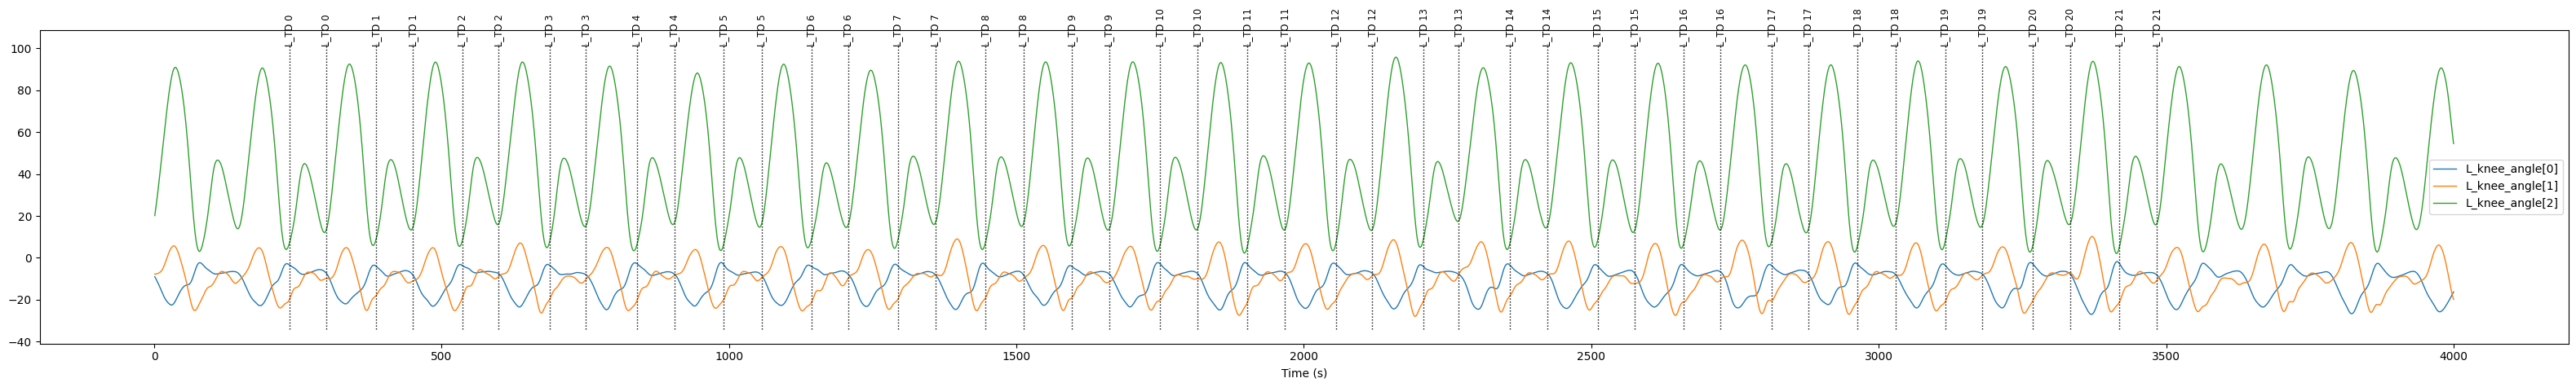

In [14]:
ts = loader.get_joint_angles_timeseries(first_session_id, "L_knee", normalized=False, include_events=True)
plt.figure(figsize=(40, 5))
ts.plot()

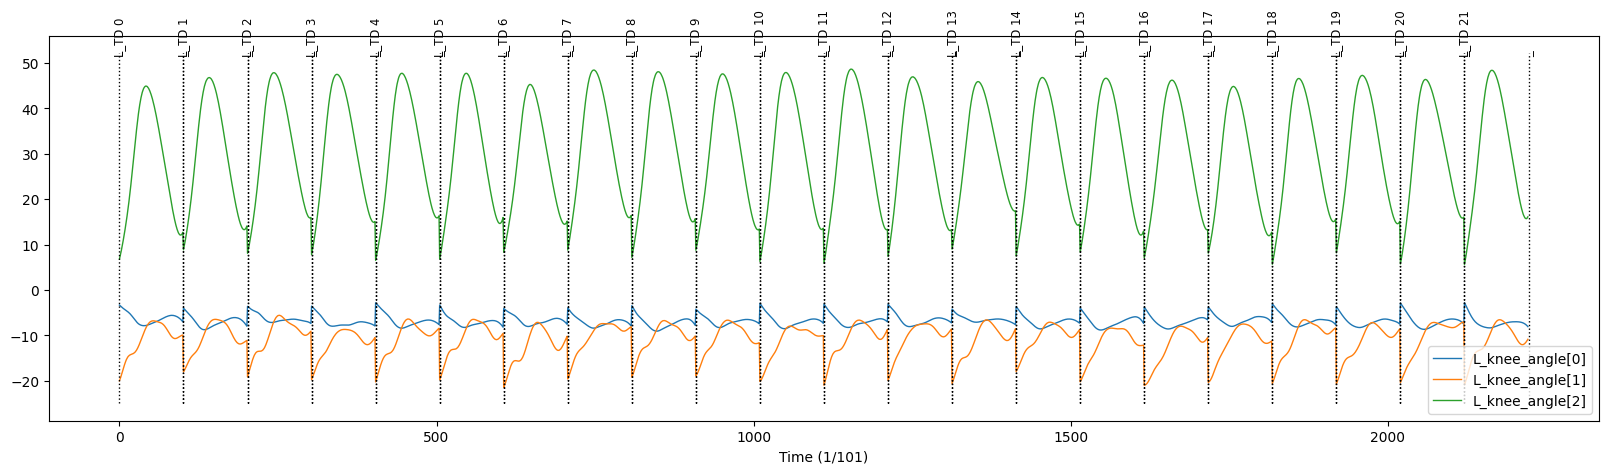

In [15]:
NUM_POINTS = 101
ts_normalized_on_stance = ktk.cycles.time_normalize(
    ts, event_name1="L_TD", event_name2="L_TO", n_points=NUM_POINTS
)

plt.figure(figsize=(20, 5))
ts_normalized_on_stance.plot("L_knee_angle")

In [16]:
data = ktk.cycles.stack(ts_normalized_on_stance, n_points=NUM_POINTS)
print(data["L_knee_angle"].shape)

(22, 101, 3)


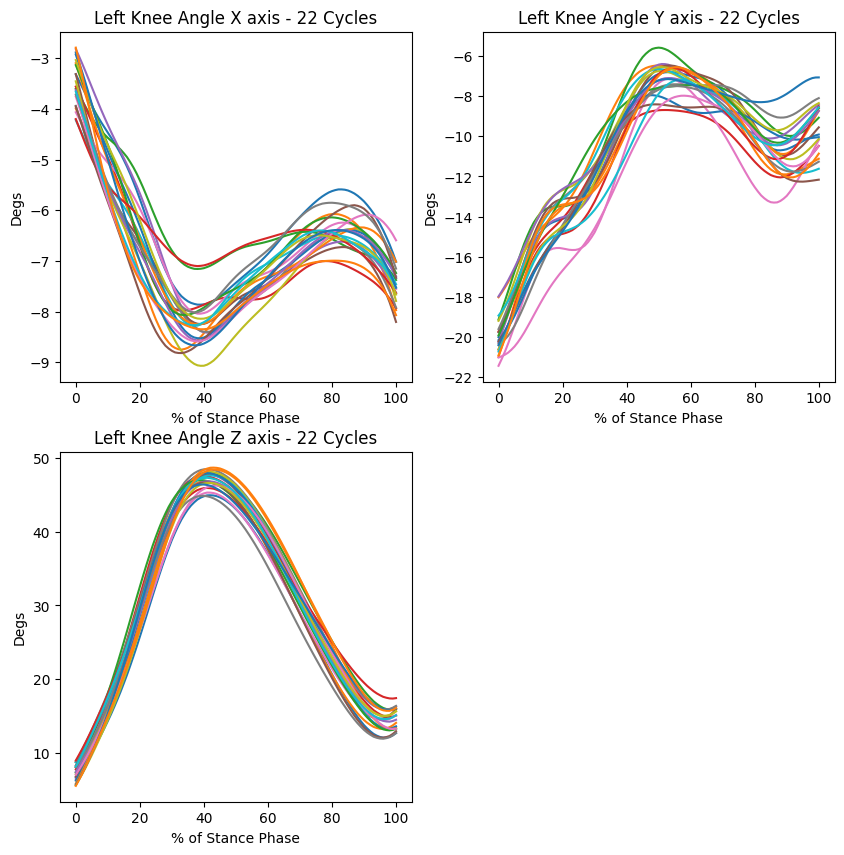

In [17]:
n_cycles = data["L_knee_angle"].shape[0]

plt.figure(figsize=(10, 10))
for i, axis in enumerate(["X", "Y", "Z"]):
    ax = plt.subplot(2,2,i + 1)
    for i_cycle in range(n_cycles):
        plt.plot(data["L_knee_angle"][i_cycle][:,i])
    plt.title(f"Left Knee Angle {axis} axis - {n_cycles} Cycles")
    plt.xlabel("% of Stance Phase")
    plt.ylabel("Degs")

# Now time to use the finidings from above

### Compare visualizations of two samples:

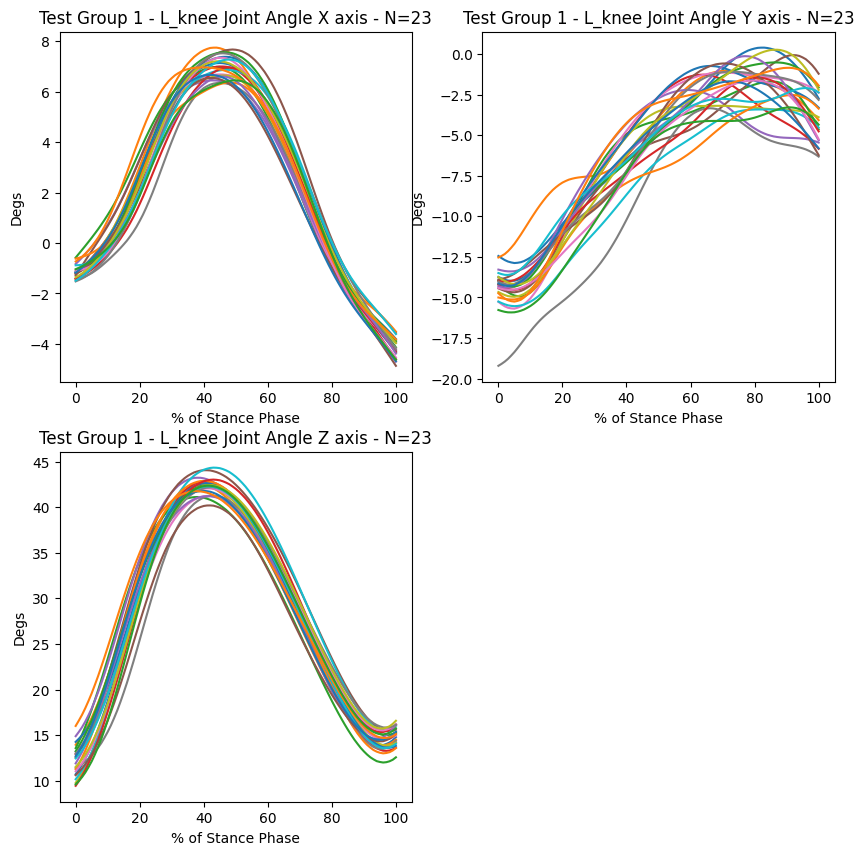

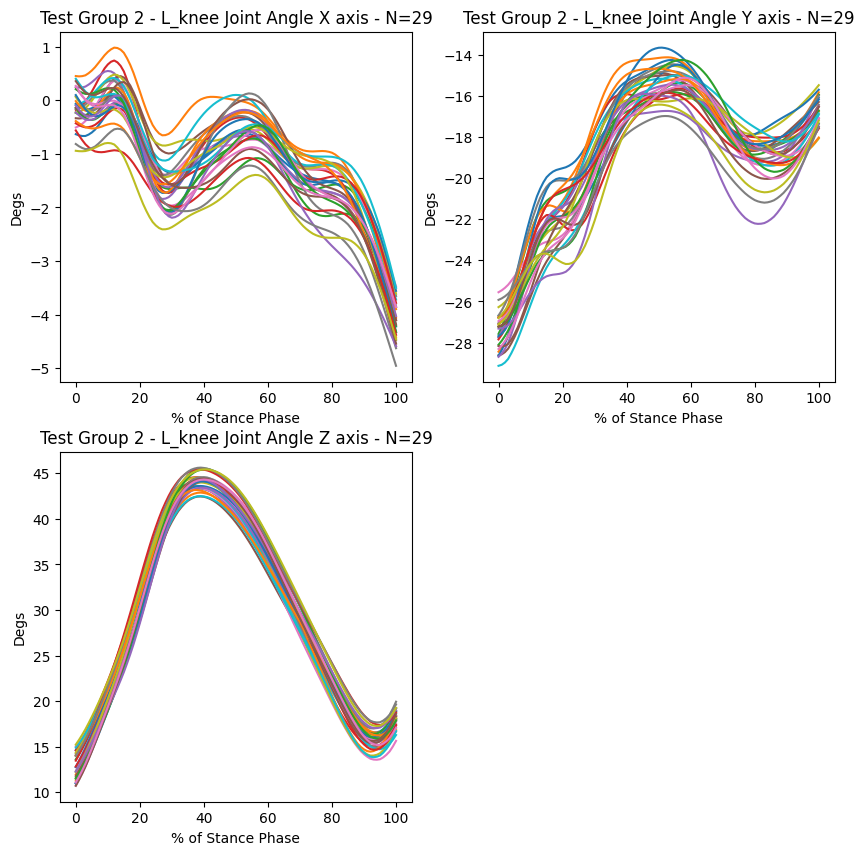

In [18]:
L_KNEE_JOINT_NAME = "L_knee"

one_session = loader.get_successful_sessions()[16]
one_session_ts = loader.get_joint_angles_timeseries(one_session, L_KNEE_JOINT_NAME, normalized=False, include_events=True)
test1_group = get_group_curves(one_session_ts)
plot_group_curves(test1_group, "Test Group 1", f"{L_KNEE_JOINT_NAME} Joint Angle", "Degs", "% of Stance Phase")

other_session = loader.get_successful_sessions()[1200]
other_session_ts = loader.get_joint_angles_timeseries(other_session, L_KNEE_JOINT_NAME, normalized=False, include_events=True)
test2_group = get_group_curves(other_session_ts)
plot_group_curves(test2_group, "Test Group 2", f"{L_KNEE_JOINT_NAME} Joint Angle", "Degs", "% of Stance Phase")

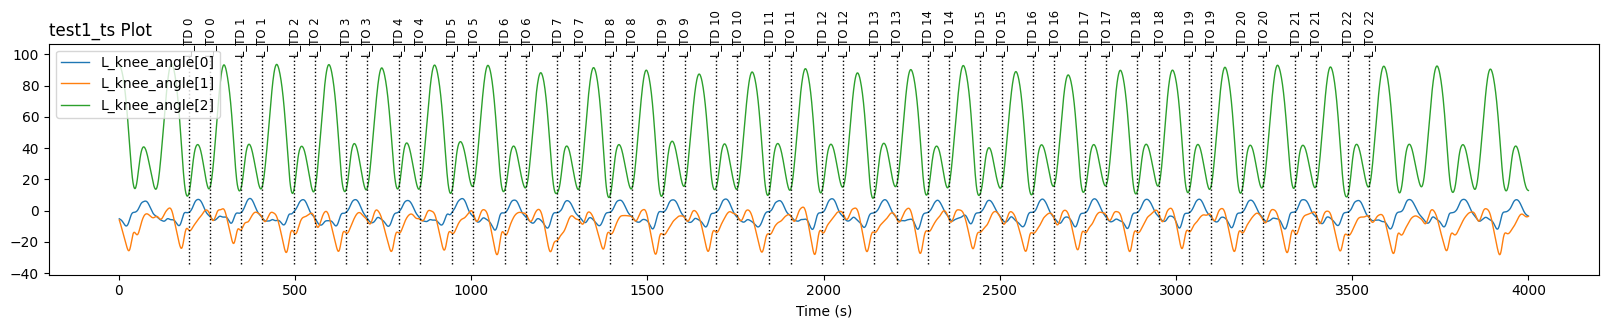

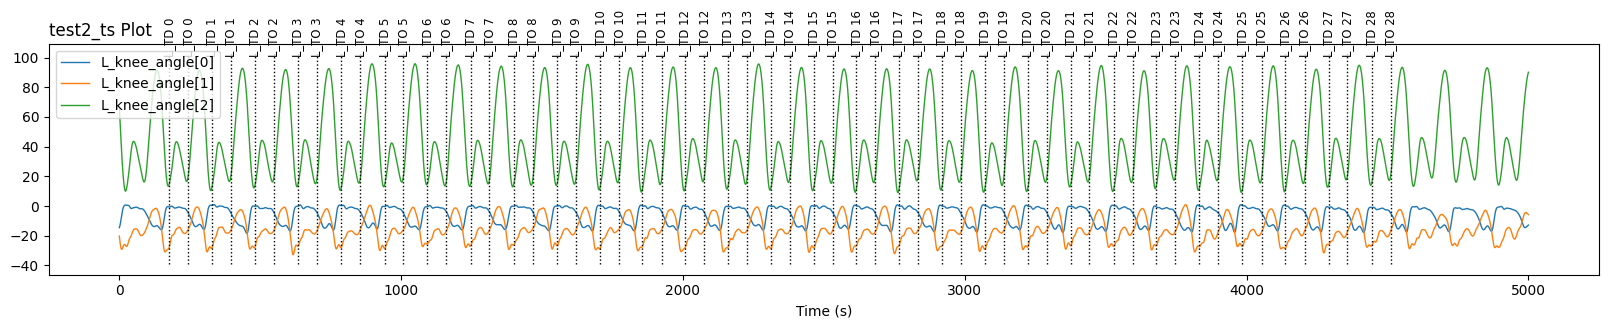

In [19]:
plt.figure(figsize=(20, 3))
one_session_ts.plot()
plt.title("test1_ts Plot", loc="left")
plt.figure(figsize=(20, 3))
other_session_ts.plot()
plt.title("test2_ts Plot", loc="left")
plt.show()

In [20]:
# GRoups for Similarity Test:
group_1 = get_group_curves(one_session_ts)
print("Group 1 shape: ", group_1.shape)
print("Group 1: Session ID: ", one_session)

group_2 = get_group_curves(other_session_ts)
print("Group 2 shape: ", group_2.shape)
print("Group 2: Session ID: ", other_session)

group_3 = get_group_curves(other_session_ts)
print("Group 3 shape: ", group_3.shape)
print("Group 3: Session ID: ", other_session)


Group 1 shape:  (23, 101, 3)
Group 1: Session ID:  100016_20110329T161600
Group 2 shape:  (29, 101, 3)
Group 2: Session ID:  101139_20140711T132738
Group 3 shape:  (29, 101, 3)
Group 3: Session ID:  101139_20140711T132738


## Averaging gait curves

We now want to average the gait curves into a single curve that represents the average.
We can see that gait curves in the same trial/session can vary a lot.

One approach is to average the curves in the same trial/session, but as explained in ["Managing variability in the summary and comparison of gait data"](https://pmc.ncbi.nlm.nih.gov/articles/PMC1208939/#sec14), this can lead to potentially losing critical curve shape characteristics and landmarks.

This other paper suggest using Curve Registration to tackle this problem.

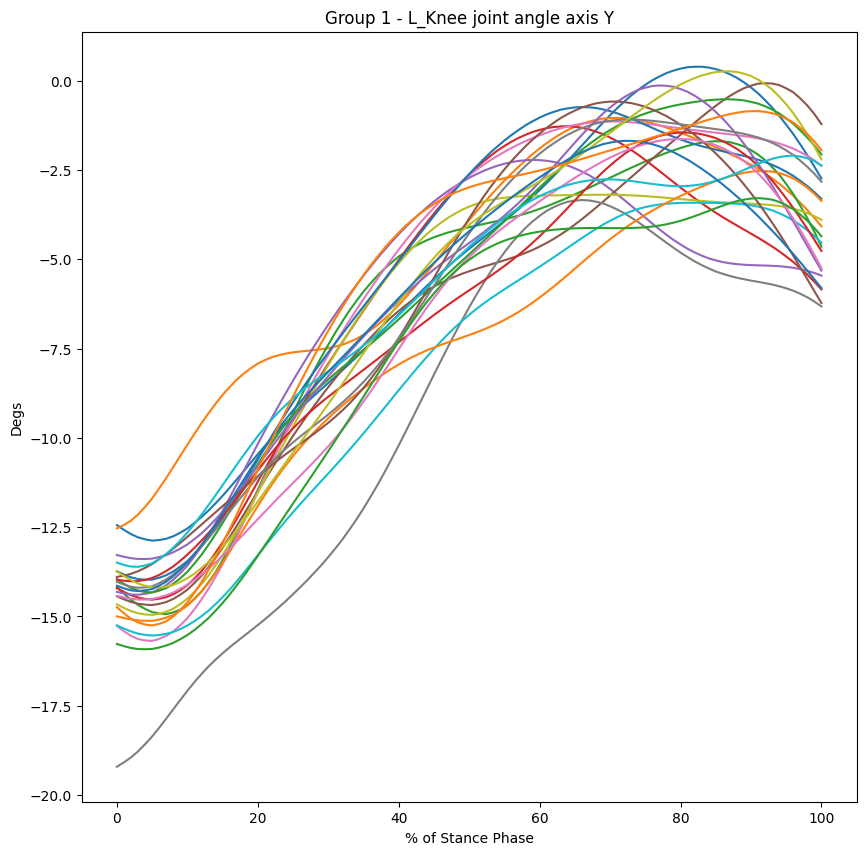

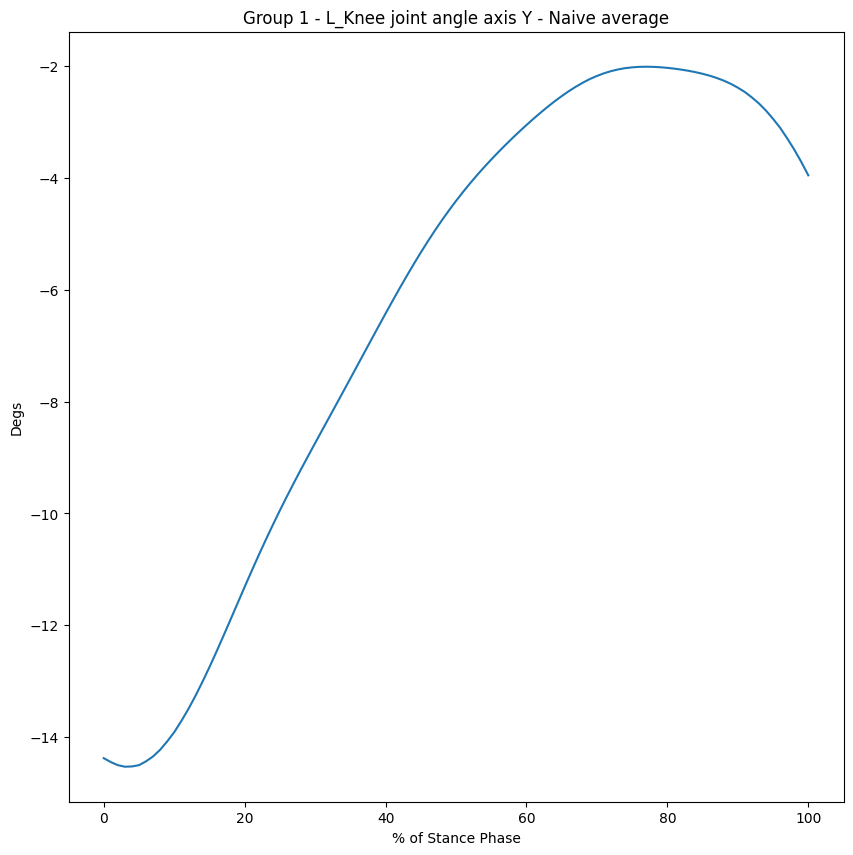

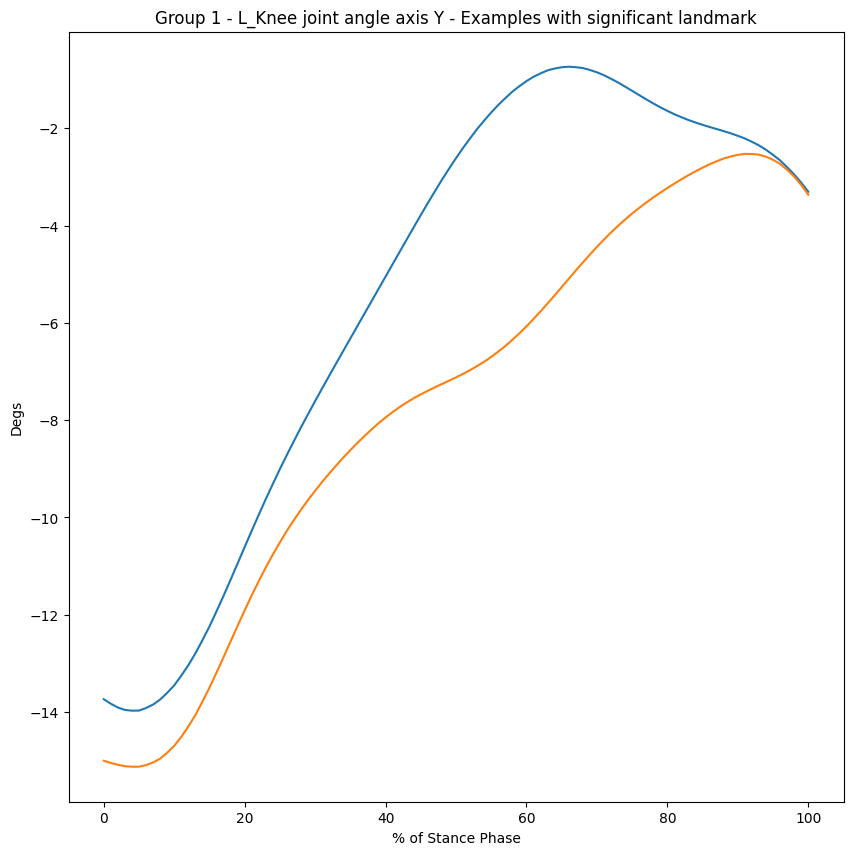

In [21]:
def plot_single_curves(single_curve, title: str, Y_axis_unit: str = "Degs", X_axis_unit: str = "% of Stance Phase"):
    """Plot a single curve of joint angle."""
    plt.figure(figsize=(10, 10))
    shape = single_curve.shape

    n_cycles = 1
    # When more than one dimension, we have a group of curves.
    if len(shape) > 1:
        n_cycles = single_curve.shape[0]
        for i_cycle in range(n_cycles):
            plt.plot(single_curve[i_cycle])
    else:
         plt.plot(single_curve)
    plt.title(title)
    plt.xlabel(X_axis_unit)
    plt.ylabel(Y_axis_unit)

# Normal
test1_group_y_axis = test1_group[:, :, 1]
plot_single_curves(test1_group_y_axis, "Group 1 - L_Knee joint angle axis Y", "Degs", "% of Stance Phase")


# Naive mean:
test1_group_y_axis_avg = test1_group_y_axis.mean(axis=0)
plot_single_curves(test1_group_y_axis_avg, "Group 1 - L_Knee joint angle axis Y - Naive average", "Degs", "% of Stance Phase")

# Line with significant landmark:
test1_group_y_axis_avg = test1_group_y_axis[10:12, :]
plot_single_curves(test1_group_y_axis_avg, "Group 1 - L_Knee joint angle axis Y - Examples with significant landmark", "Degs", "% of Stance Phase")


# avg_test2_group = test2_group.mean(axis=0)
# plot_group_curves(test2_group, "Test Group 2", f"{L_KNEE_JOINT_NAME} Joint Angle", "Degs", "% of Stance Phase")

### Curve registration

Algorithm:

1. Compute an initial mean curve by averaging the unregistered curves pointwise.
2. For each individual curve, estimate a smooth, monotone time-warping function that aligns that curve’s features (such as peak values) to the mean curve’s corresponding features. This accounts for variations in timing (phase shifts) across trials.
3. Apply the warping function to align the curve to the mean.
4. Re-calculate the mean curve by averaging all registered (aligned) curves.
Repeat steps 3–5 iteratively until convergence; typically, a single iteration suffices.


Convergence after 25 iterations!


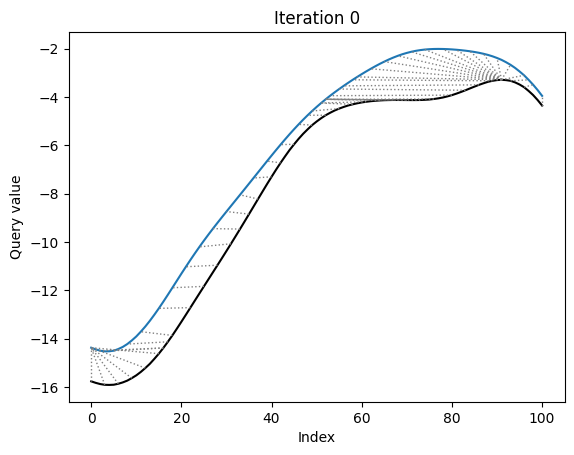

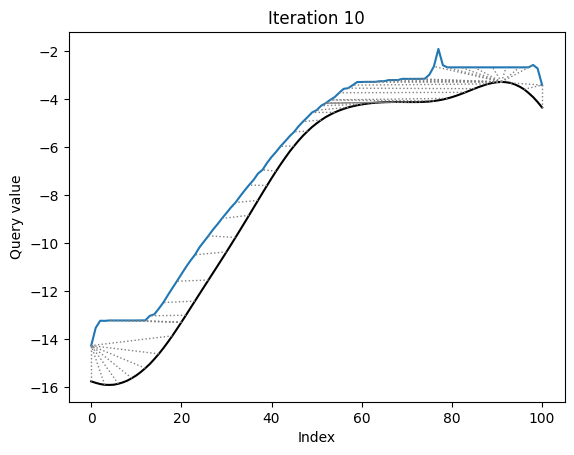

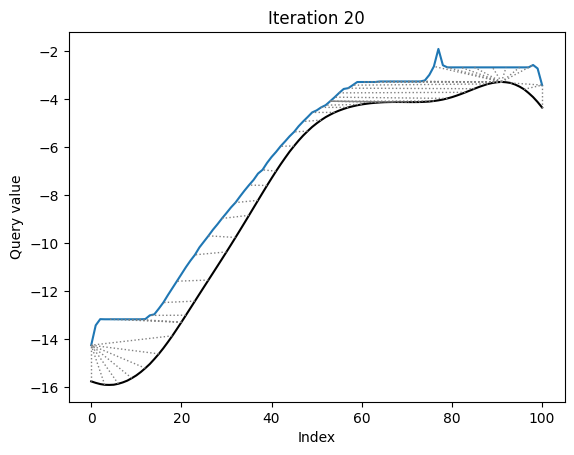

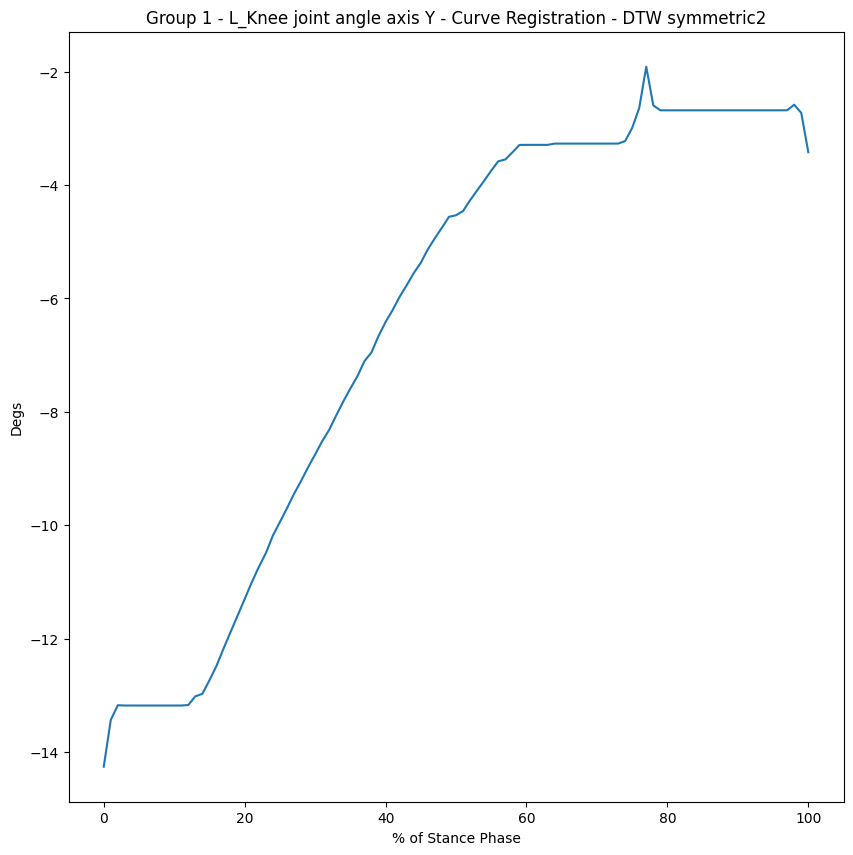

In [22]:
re_test1_group_y_axis = apply_continuous_curve_registration(test1_group_y_axis, max_iter=10000, plot_dtw=True, plot_type="twoway", step_pattern="symmetric2")
plot_single_curves(re_test1_group_y_axis, "Group 1 - L_Knee joint angle axis Y - Curve Registration - DTW symmetric2", "Degs", "% of Stance Phase")

Convergence after 32 iterations!


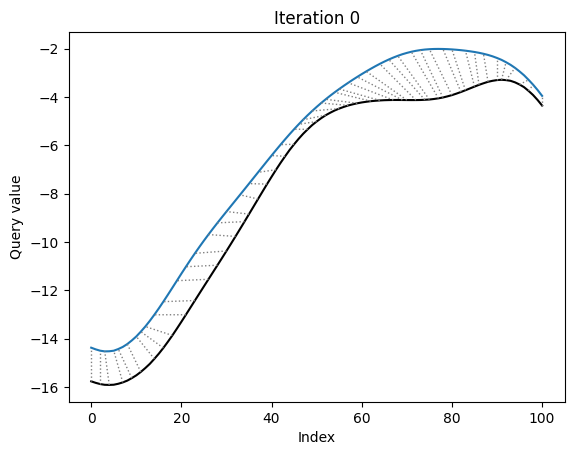

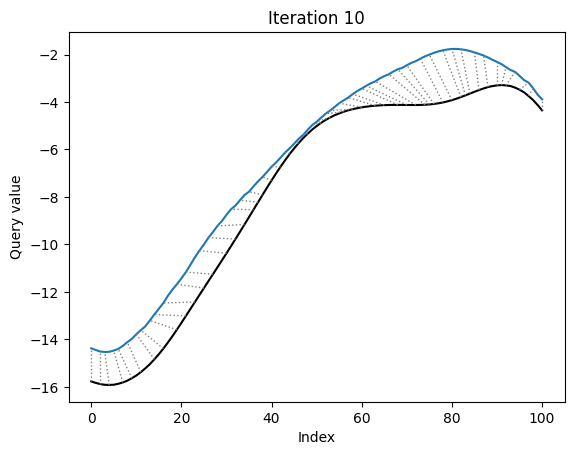

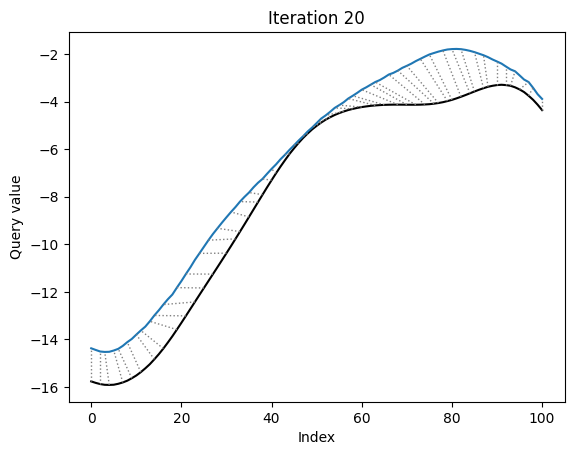

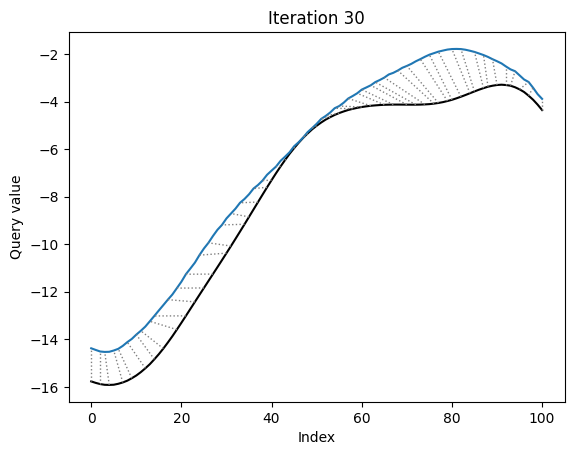

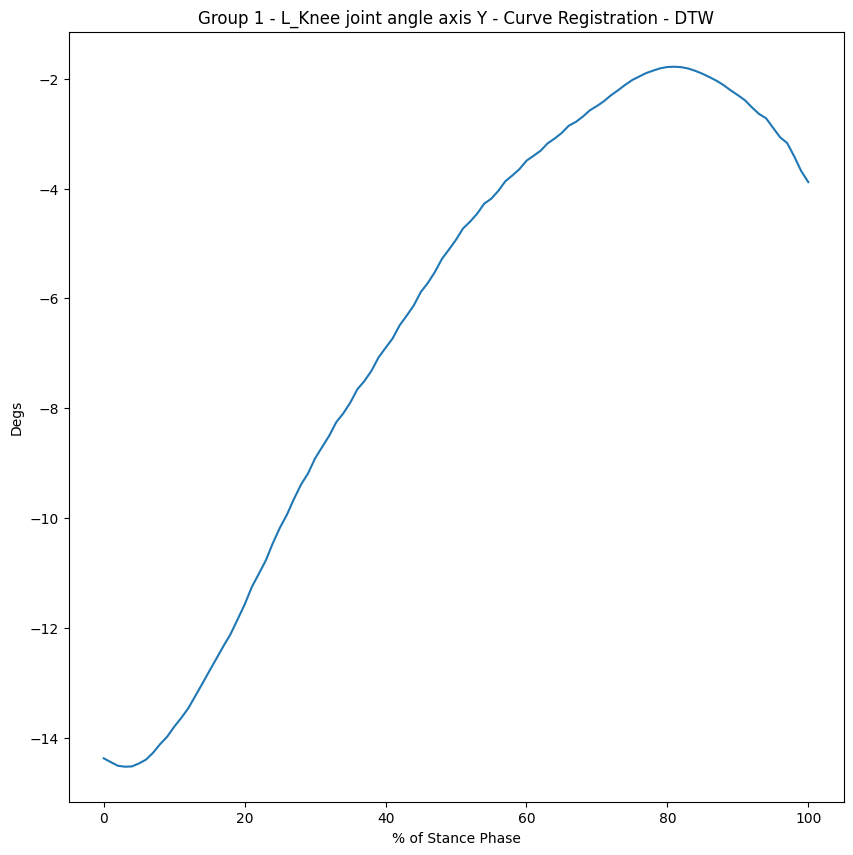

In [23]:
re_test1_group_y_axis = apply_continuous_curve_registration(test1_group_y_axis, max_iter=10000, plot_dtw=True, plot_type="twoway")

plot_single_curves(re_test1_group_y_axis, "Group 1 - L_Knee joint angle axis Y - Curve Registration - DTW", "Degs", "% of Stance Phase")

Convergence after 46 iterations!


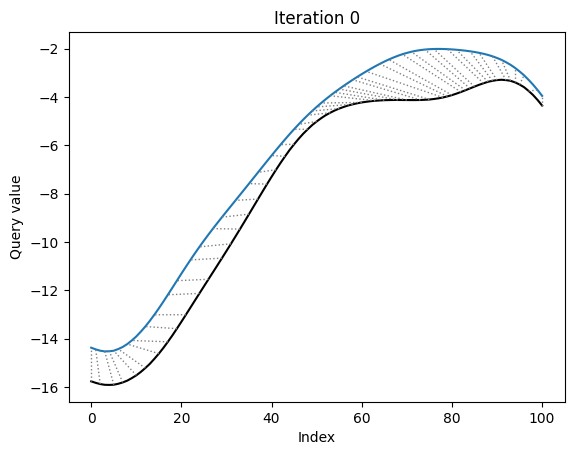

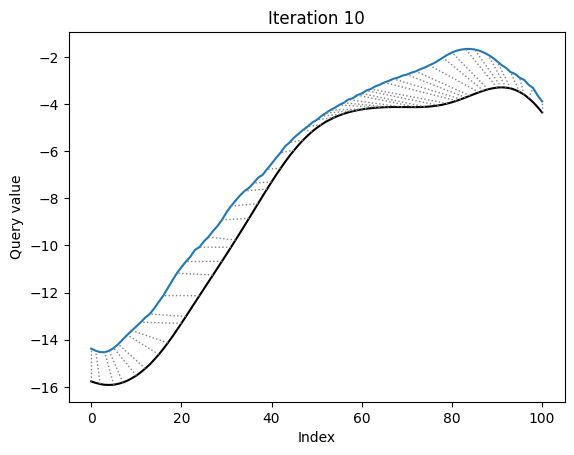

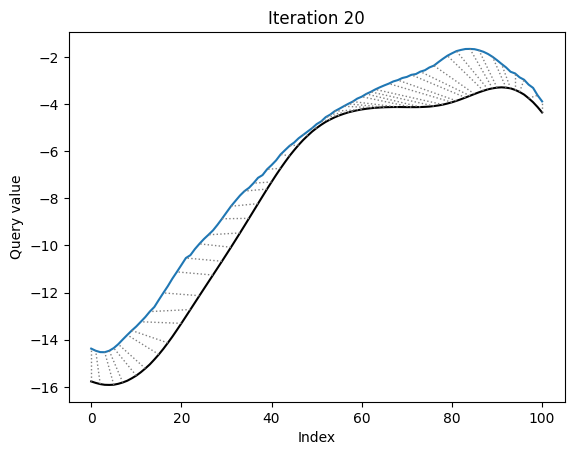

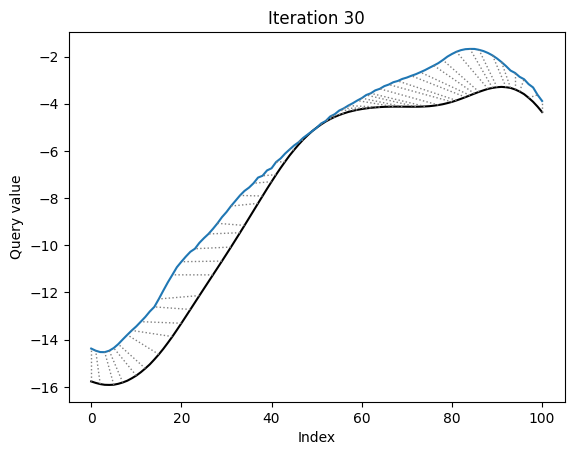

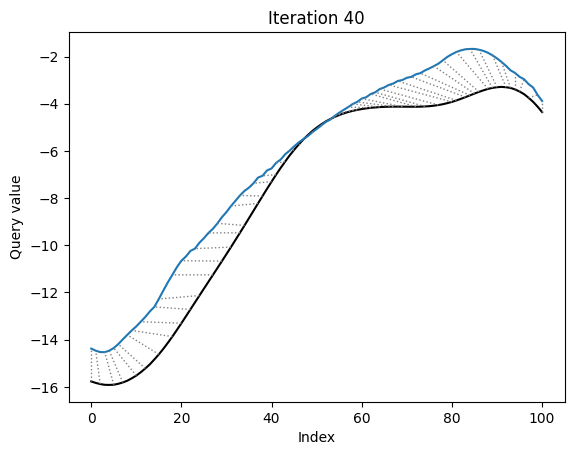

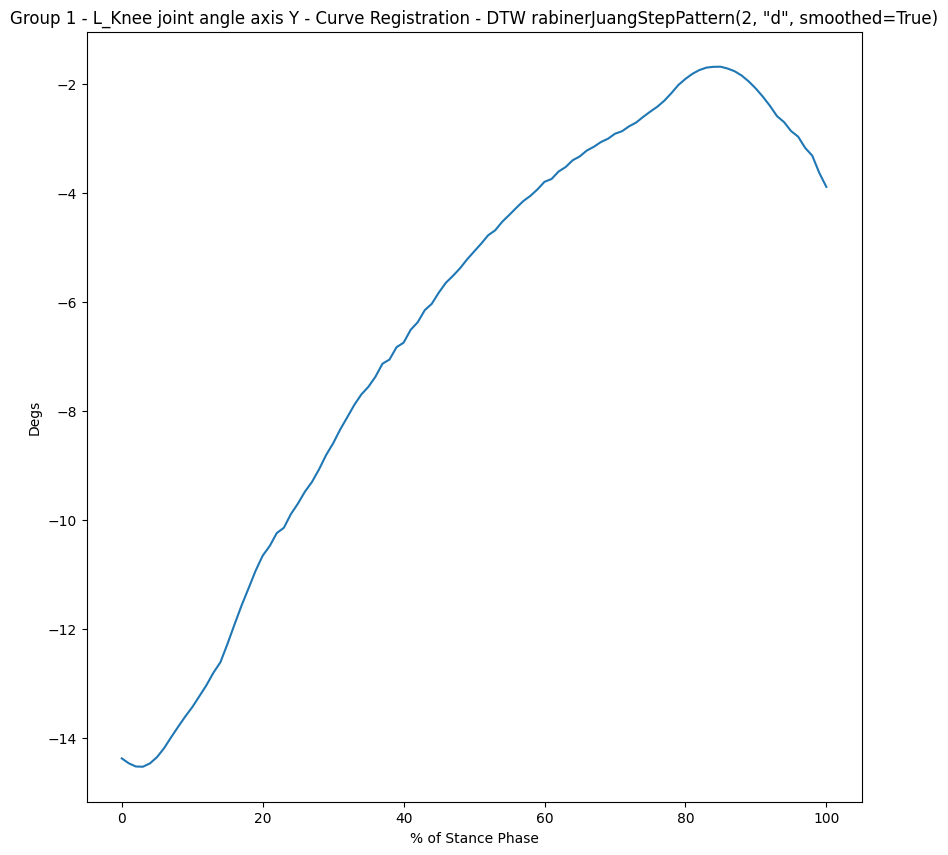

In [24]:
re_test1_group_y_axis = apply_continuous_curve_registration(test1_group_y_axis, max_iter=100, plot_dtw=True, plot_rate=10, plot_type="twoway",
    step_pattern=dtw.rabinerJuangStepPattern(2, "d", smoothed=True)
)

plot_single_curves(
    re_test1_group_y_axis,
    'Group 1 - L_Knee joint angle axis Y - Curve Registration - DTW rabinerJuangStepPattern(2, "d", smoothed=True)',
    "Degs",
    "% of Stance Phase"
)

## Alternative implementation of curve registration

In [25]:
# Alternative implementation of curve registration

import numpy as np
from scipy.integrate import simpson
from scipy.optimize import minimize_scalar
import warnings

def compute_inner_products(f_s, g_s, s):
    f2 = f_s * f_s
    g2 = g_s * g_s
    fg = f_s * g_s
    a = simpson(f2, s)
    b = simpson(fg, s)
    c = simpson(g2, s)
    return a, b, c

def smallest_eigenvalue(a, b, c):
    trace = a + c
    det = a * c - b * b
    discr = np.sqrt(max(trace*trace - 4*det, 0.0))
    return (trace - discr) / 2.0

def register_curves(curves, max_iter=10, tol=1e-6, shift_bounds=(-0.2, 0.2)):
    """
    Perform continuous registration (time-shift only) of curves to their mean.
    
    Parameters
    ----------
    curves : ndarray, shape (N, M)
        N curves each sampled at M points on s∈[0,1].
    max_iter : int
        Maximum number of iterations.
    tol : float
        Convergence tolerance for template change.
    shift_bounds : tuple
        Min/max allowable shift (in same units as s).
    
    Returns
    -------
    registered : ndarray, shape (N, M)
        The time‐shift‐registered curves.
    template : ndarray, shape (M,)
        Final mean curve after registration.
    shifts : ndarray, shape (N,)
        Optimal shift δᵢ for each curve.
    """
    N, M = curves.shape
    s = np.linspace(0, 1, M)
    # Initialize template: cross‐sectional mean
    template = curves.mean(axis=0)
    
    for i in range(max_iter):
        if i == max_iter - 1:
            warnings.warn("Maximum number of iterations reached. The registration may not have converged.")
        
        shifts = np.zeros(N)
        registered = np.zeros_like(curves)
        
        # Precompute template norms
        _, _, cc = compute_inner_products(template, template, s)
        
        # Align each curve by optimal shift
        for i in range(N):
            xi = curves[i]
            
            def objective(delta):
                # shift xi by delta via linear interpolation
                warped = np.interp(s, s - delta, xi, left=xi[0], right=xi[-1])
                a, b, _ = compute_inner_products(warped, template, s)
                return smallest_eigenvalue(a, b, cc)
            
            res = minimize_scalar(objective, bounds=shift_bounds, method='bounded')
            δ_opt = res.x
            shifts[i] = δ_opt
            registered[i] = np.interp(s, s - δ_opt, xi, left=xi[0], right=xi[-1])
        
        # Update template
        new_template = registered.mean(axis=0)
        diff = np.linalg.norm(new_template - template) / np.linalg.norm(template)
        template = new_template
        
        if diff < tol:
            break
    
    return registered, template, shifts


Optimal shifts: [-0.14615018 -0.1968894  -0.18675905 -0.19999376 -0.19999376 -0.15413091
 -0.19999376 -0.15497539 -0.19999376 -0.09309661 -0.19999376 -0.09579822
 -0.1674967  -0.12271008 -0.15854483 -0.15788006 -0.12542482 -0.15736528
 -0.16581918 -0.16909306 -0.18370877 -0.19999376 -0.14899134]


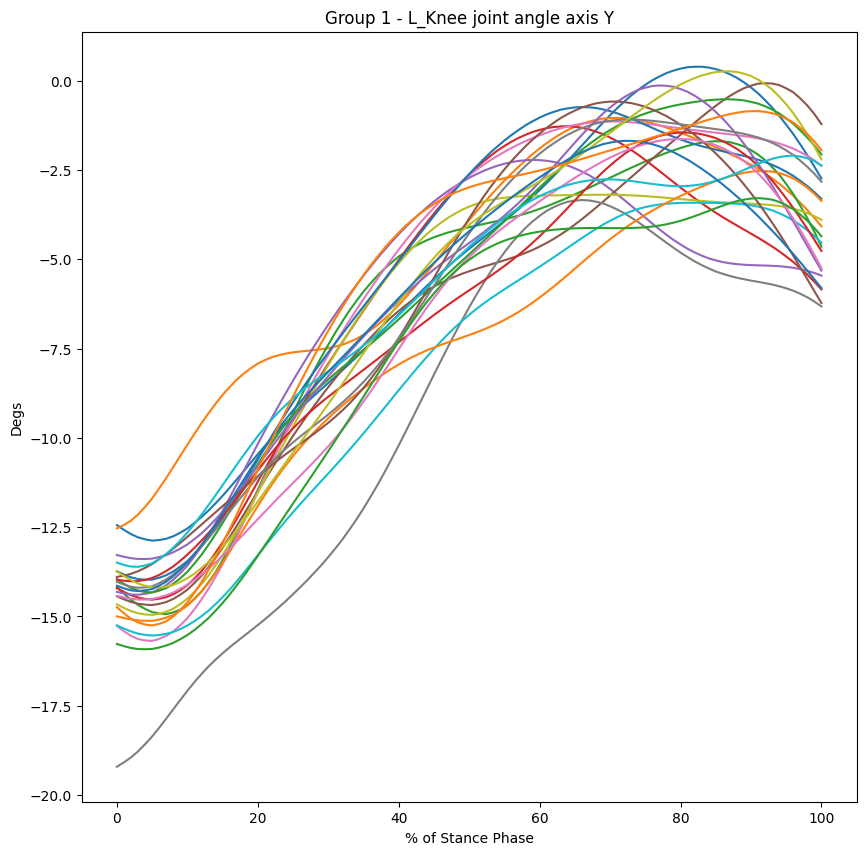

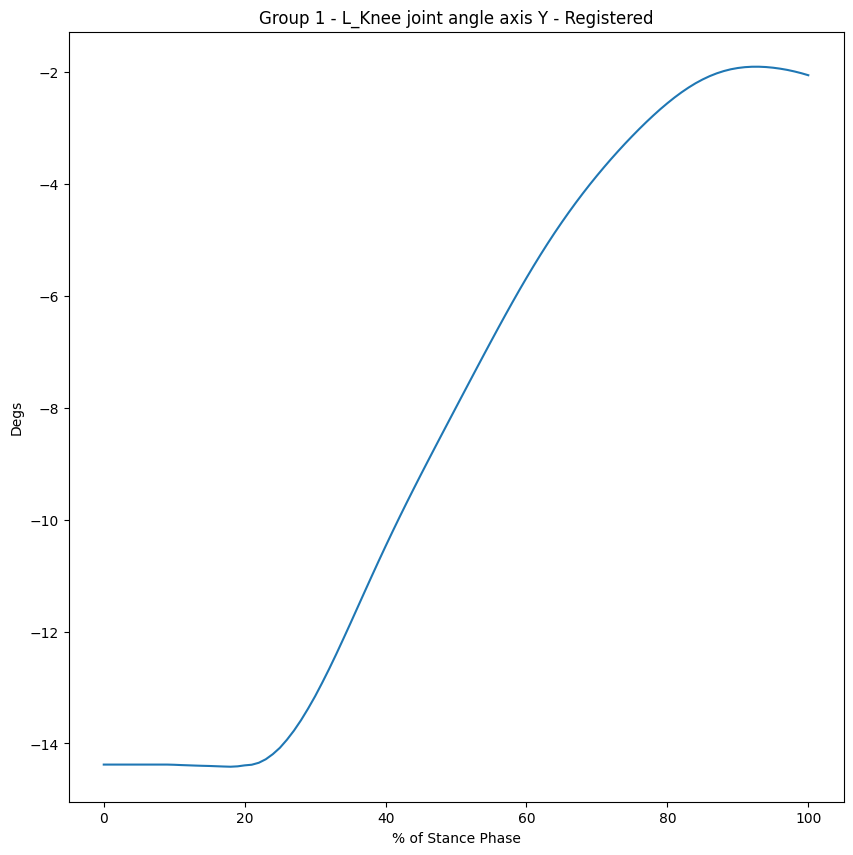

In [27]:
plot_single_curves(test1_group_y_axis, "Group 1 - L_Knee joint angle axis Y", "Degs", "% of Stance Phase")

registered, final_template, shifts = register_curves(test1_group_y_axis, shift_bounds=(-0.2, 0.2), max_iter=10000)
print("Optimal shifts:", shifts)
plot_single_curves(final_template, "Group 1 - L_Knee joint angle axis Y - Registered", "Degs", "% of Stance Phase")